
# 09. 부품 연결로 새 문제 풀기: 사다리 4단계 "쌓으며 크기" 졸업 시험

**문제**: 사람들이 기준 문(빨강/파랑/초록)의 열쇠에 대해 말투를 섞어 말한다. 누가 믿을 만한지는 경험으로 알아내야 한다. 안내판은 "같은 열쇠" 고리를 알려 준다. 질문은 고리 끝의 문에 대해 한다.
→ **1단계 부품(누구를 믿을까)**과 **3단계 부품(생각 루프)**이 둘 다 필요하다.

| 방식 | 무엇을 학습하나 | 학습 파라미터 | seed당 시간 |
|---|---|---:|---:|
| **성장형** | 부품을 얼리고, 연결 장치(어댑터)만 "충실한 전달"로 학습 | **184** | **25초** |
| 전부 고쳐 쓰기 | 부품을 불러와서 전부 학습 | 51,444 | 12분 |
| 처음부터 | 같은 구조를 새로 초기화해서 전부 학습 | 51,444 | 12분 |

모두 같은 데이터(학습 세션 300개, 1단계의 1/10)를 쓰고, 새 시험 세션으로 평가했다.


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()
SEEDS = (42, 43, 44)
ARMS = [("grown", "성장형", V.BLUE), ("retune", "전부 고쳐 쓰기", V.ORANGE), ("scratch", "처음부터", V.NEUTRAL)]
runs = {(a, s): json.loads((S.RESULTS / f"world-v4_{a}_seed-{s}.json").read_text(encoding="utf-8")) for a, _, _ in ARMS for s in SEEDS}
v3 = {s: json.loads((S.RESULTS / f"world-v3_thinker-grown_seed-{s + 3}.json").read_text(encoding="utf-8"))["test"]["adaptive"] for s in SEEDS}
for a, label, _ in ARMS:
    print(f"{label:10s}", [runs[(a, s)]["test"]["score"] for s in SEEDS])
print("신뢰 부품 단독", [runs[("grown", s)]["test"]["trust_part_alone"] for s in SEEDS])


성장형        [0.4485, 0.4278, 0.476]
전부 고쳐 쓰기   [0.439, 0.0003, 0.0]
처음부터       [0.0, 0.0003, 0.0]
신뢰 부품 단독 [0.4485, 0.4283, 0.476]



## 1. 새 문제 점수

점선은 신뢰 부품 혼자서 기준 문을 맞힌 점수다. 고리는 정확하므로 이것이 합친 시스템의 상한이다.


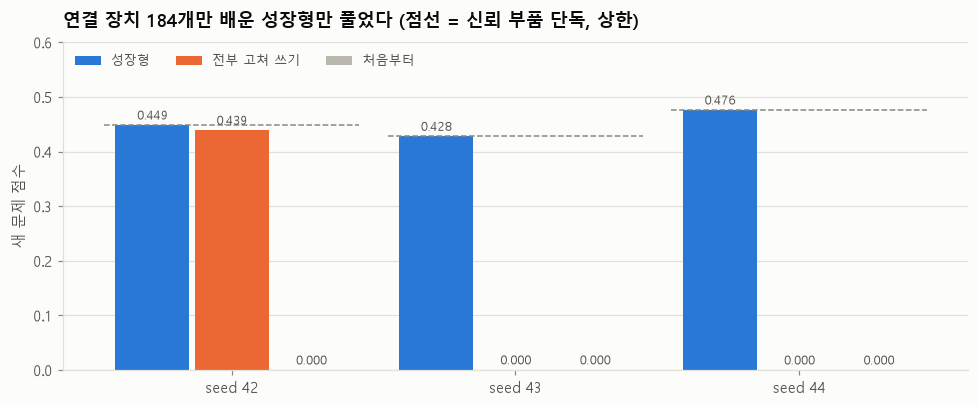

In [2]:

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(SEEDS))
w = 0.26
for i, (a, label, color) in enumerate(ARMS):
    values = [runs[(a, s)]["test"]["score"] for s in SEEDS]
    ax.bar(x + (i - 1) * (w + 0.02), values, width=w, color=color, label=label)
    for xi, v in zip(x, values):
        ax.text(xi + (i - 1) * (w + 0.02), v + 0.01, f"{v:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
for xi, s in zip(x, SEEDS):
    top = runs[("grown", s)]["test"]["trust_part_alone"]
    ax.plot([xi - 0.45, xi + 0.45], [top, top], "--", color=V.MUTED, lw=1)
ax.set_xticks(x, [f"seed {s}" for s in SEEDS])
ax.set_ylim(0, 0.6)
ax.grid(axis="x", visible=False)
ax.set_ylabel("새 문제 점수")
ax.legend(fontsize=8.5, frameon=False, ncol=3, loc="upper left")
ax.set_title("연결 장치 184개만 배운 성장형만 풀었다 (점선 = 신뢰 부품 단독, 상한)", pad=10)
fig.tight_layout()
plt.show()



## 2. 새로 배운 뒤 예전 능력

- 왼쪽: 신뢰 능력(v2-H 시험 세션에서 신뢰 부품 단독 점수)
- 오른쪽: 생각 능력(3단계 시험)
- 회색 점은 원래 값이다.


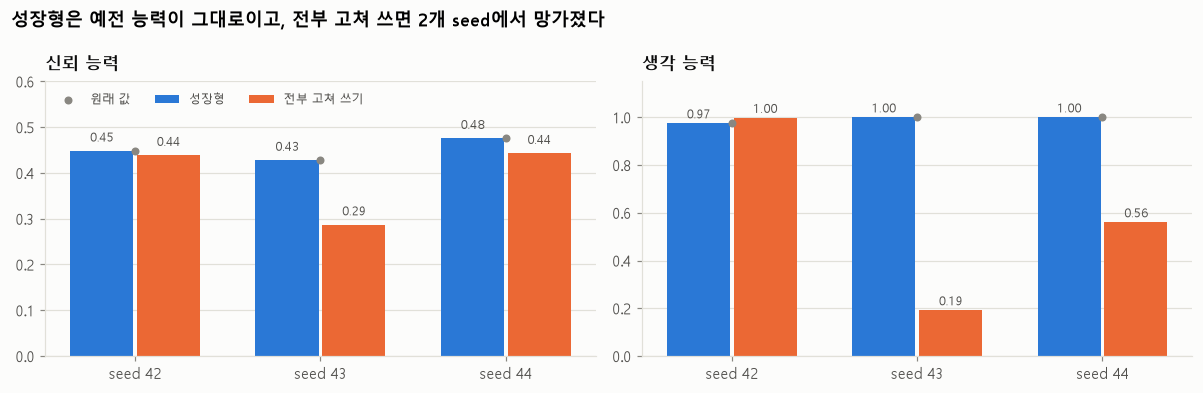

In [3]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (key, title, original) in zip(axes, [
        ("trust_v2h_test", "신뢰 능력", {s: runs[("grown", s)]["old_abilities"]["trust_v2h_test"] for s in SEEDS}),
        ("thinker_v3_test", "생각 능력", v3)]):
    for i, (a, label, color) in enumerate(ARMS[:2]):
        values = [runs[(a, s)]["old_abilities"][key] for s in SEEDS]
        ax.bar(x + (i - 0.5) * 0.36, values, width=0.34, color=color, label=label)
        for xi, v in zip(x, values):
            ax.text(xi + (i - 0.5) * 0.36, max(v, 0) + 0.02, f"{v:.2f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
    ax.scatter(x, [original[s] for s in SEEDS], color=V.MUTED, zorder=3, s=18, label="원래 값")
    ax.set_xticks(x, [f"seed {s}" for s in SEEDS])
    ax.set_ylim(0, 1.15 if key == "thinker_v3_test" else 0.6)
    ax.grid(axis="x", visible=False)
    ax.set_title(title, fontsize=11, pad=8)
axes[0].legend(fontsize=8, frameon=False, loc="upper left", ncol=3)
fig.suptitle("성장형은 예전 능력이 그대로이고, 전부 고쳐 쓰면 2개 seed에서 망가졌다", x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 3. 정리

- **4단계 졸업.** 미리 정한 기준을 모두 통과했다.
  - (a) 성장형 = 신뢰 부품 단독 (차이 0, 0.0005, 0). 연결에서 잃는 것이 없다.
  - (b) 성장형 − 처음부터 = +0.45 (평균).
  - (c) 성장형의 예전 능력이 그대로다(얼렸으므로).
- **전부 고쳐 쓰기**는 seed 42에서만 풀었다(0.439). seed 43과 44에서는 새 문제 0.000이었고, 예전 능력도 망가졌다(신뢰 0.43 → 0.29, 생각 1.0 → 0.19와 0.56). 학습 파라미터가 280배 많은데도 그렇다.
- **처음부터**는 경험 300세션으로는 아무것도 배우지 못했다(0.000). 1단계 때는 3,000세션을 썼다.
- **과정에서 배운 것**(설계 문서에 시도별로 기록):
  1. 애매한 확률을 넘기면 실패했다. 확실한 사실만 보고 자란 생각 부품은 불확실성을 나르지 못한다.
  2. 결론을 넘기되 진짜 정답으로 학습하면 실패했다. 연결 장치가 신뢰 부품의 실수를 피해 "모름"으로 숨는다.
  3. **연결은 "충실한 전달"로 학습해야 한다.** 맞히는 건 판단 부품의 몫이다. 이 방식은 정답이 필요 없다.
- 한계: 연결 방식(사람 말 → 신뢰 부품, 안내판 → 생각 부품)은 출처로 정했고, 학습한 게 아니다. 처음부터 방식은 데이터가 적어서 졌을 뿐, 데이터가 많으면 배울 수 있다.
